# Machine Learning Assignment: Emotion Recognition from Text

**Assignment type:** Text Analysis / Natural Language Processing  
**Learning type:** Supervised Multiclass Classification  
**Learning algorithm:** Multiclass Logistic Regression using scikit-learn  
**Dataset:** [Emotions dataset for NLP - Kaggle](https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp)

This notebook presents a complete supervised learning workflow: loading the original
Train, Validation, and Test files, exploratory data analysis, TF-IDF feature engineering,
training a Logistic Regression classifier, hyperparameter comparison using the Validation
set, final training, prediction, and evaluation on the untouched Test set.

## Student Details & GenAI Declaration

**Students:** Maor C. (212694004), Lucas B. (346802507), Noam K. (211495510)
**Course:** Machine Learning

---

### AI Utilization Statement
Generative AI (ChatGPT) was used as a learning assistant for writing visualization code, debugging errors, and organizing the hyperparameter grid search. All modeling decisions, evaluation analysis, and final code execution were done by the team.

### Prompts Examples:
1. *"How can I plot both the class distribution and text length histogram side-by-side using Seaborn?"*
2. *"Show me an example of running GridSearchCV on LogisticRegression with TF-IDF using a validation set in scikit-learn."*
3. *"Write a clean Python function to display a Confusion Matrix with clear class labels instead of numeric indices."*

---

### Additional Sources & References
1. **Scikit-Learn Documentation:** *Feature Extraction (`TfidfVectorizer`) & `LogisticRegression` API reference*.
2. **Kaggle Dataset:** *Emotions Dataset for NLP (6 classes)*.
3. **Python Libraries:** `pandas`, `seaborn`, `matplotlib`, `scikit-learn`.

## Learning Problem and Dataset

The objective is to receive an English sentence and classify its expressed emotion into
one of six categories: `anger`, `fear`, `joy`, `love`, `sadness`, or `surprise`. This is a
supervised multiclass classification problem because every training sentence has a known
target label.

The dataset contains 20,000 text samples and is already divided into 16,000 Train samples,
2,000 Validation samples, and 2,000 Test samples. No file is split again. The Validation
set is used for hyperparameter selection, while the Test set is reserved for the final
evaluation only.

**Primary quality metric:** Macro-F1. It calculates the F1-score independently for every
class and then takes their unweighted average. Therefore, rare emotions such as `surprise`
receive the same importance as frequent emotions such as `joy`.

In [89]:
# Imports and reproducibility
import io
from pathlib import Path
import random
import re
import urllib.request
import zipfile

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.preprocessing import LabelEncoder

# Set global seed for full reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Display & Visual Settings
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", palette="muted", context="notebook")

print("Environment initialized successfully. Global Random Seed:", SEED)

Environment initialized successfully. Global Random Seed: 42


## Downloading and Loading the Original Files

The next cell uses the included local files when they are available. If the notebook is
opened in a new Colab environment, it downloads the public Kaggle archive and extracts it.
The three original files are loaded separately, with no additional Train/Test split.

In [90]:
DATA_DIR = Path("data")
REQUIRED_FILES = ["train.txt", "val.txt", "test.txt"]
KAGGLE_DOWNLOAD_URL = (
    "https://www.kaggle.com/api/v1/datasets/download/"
    "praveengovi/emotions-dataset-for-nlp?datasetVersionNumber=1"
)


def ensure_dataset(data_dir=DATA_DIR):
    data_dir.mkdir(parents=True, exist_ok=True)
    if all((data_dir / filename).exists() for filename in REQUIRED_FILES):
        print("Using the dataset files included with the submission.")
        return

    print("Dataset files were not found; downloading the public Kaggle archive...")
    with urllib.request.urlopen(KAGGLE_DOWNLOAD_URL, timeout=120) as response:
        archive_bytes = response.read()
    with zipfile.ZipFile(io.BytesIO(archive_bytes)) as archive:
        archive.extractall(data_dir)
    print("Download completed.")


def load_split(path):
    rows = []
    with open(path, encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            line = line.rstrip("\n")
            if not line:
                continue
            try:
                text, label = line.rsplit(";", 1)
            except ValueError as error:
                raise ValueError(f"Invalid row {line_number} in {path}") from error
            rows.append((text, label))
    return pd.DataFrame(rows, columns=["text", "label"])


ensure_dataset()
train_df = load_split(DATA_DIR / "train.txt")
val_df = load_split(DATA_DIR / "val.txt")
test_df = load_split(DATA_DIR / "test.txt")

print(f"Train: {len(train_df):,} rows")
print(f"Validation: {len(val_df):,} rows")
print(f"Test: {len(test_df):,} rows")
print(f"Total: {len(train_df) + len(val_df) + len(test_df):,} rows")


Using the dataset files included with the submission.
Train: 16,000 rows
Validation: 2,000 rows
Test: 2,000 rows
Total: 20,000 rows


### First Five Train Rows


In [91]:
display(train_df.head())


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,love
4,i am feeling grouchy,anger


### First Five Validation Rows

In [92]:
display(val_df.head())

,text,label
0,im feeling quite sad and sorry for myself but ill snap out of it soon,sadness
1,i feel like i am still looking at a blank canvas blank pieces of paper,sadness
2,i feel like a faithful servant,love
3,i am just feeling cranky and blue,anger
4,i can have for a treat or if i am feeling festive,joy


### First Five Test Rows

In [93]:
display(test_df.head())

,text,label
0,im feeling rather rotten so im not very ambitious right now,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy
4,i was feeling a little vain when i did this one,sadness


## Data Quality and Exploratory Analysis

This section checks missing values, duplicate rows, and unexpected labels. It also
presents the class distribution and sentence lengths. The classes are not balanced:
`joy` and `sadness` are much more common than `surprise`. This supports the use of
Macro-F1 as the primary metric.

In [94]:
splits = {"Train": train_df, "Validation": val_df, "Test": test_df}
quality_rows = []
for split_name, frame in splits.items():
    quality_rows.append({
        "split": split_name,
        "rows": len(frame),
        "missing_text": int(frame["text"].isna().sum()),
        "missing_label": int(frame["label"].isna().sum()),
        "duplicate_rows": int(frame.duplicated().sum()),
        "unique_labels": frame["label"].nunique(),
    })

quality_df = pd.DataFrame(quality_rows)
display(quality_df)

expected_labels = {"anger", "fear", "joy", "love", "sadness", "surprise"}
observed_labels = set(pd.concat([train_df, val_df, test_df])["label"].unique())
assert observed_labels == expected_labels, observed_labels
assert quality_df[["missing_text", "missing_label"]].to_numpy().sum() == 0
print("Quality checks passed. Labels:", sorted(observed_labels))

,split,rows,missing_text,missing_label,duplicate_rows,unique_labels
0,Train,16000,0,0,1,6
1,Validation,2000,0,0,0,6
2,Test,2000,0,0,0,6


Quality checks passed. Labels: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']


,Train,Validation,Test,Total
label,,,,
joy,5362,704,695,6761
sadness,4666,550,581,5797
anger,2159,275,275,2709
fear,1937,212,224,2373
love,1304,178,159,1641
surprise,572,81,66,719


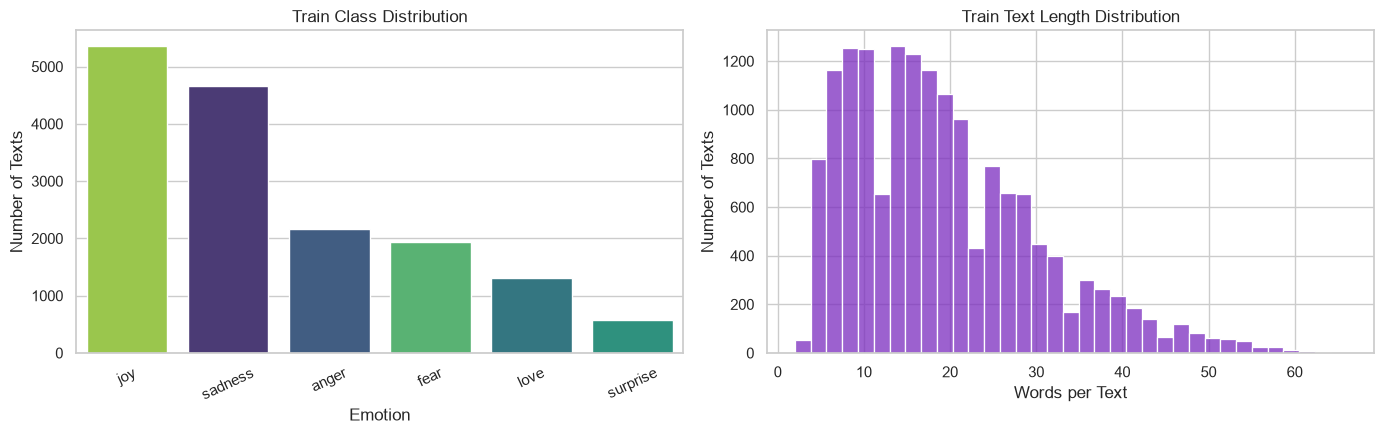

Median words per Train text: 17
95th percentile: 41


In [95]:
distribution = (
    pd.concat(
        [frame["label"].value_counts().rename(name) for name, frame in splits.items()],
        axis=1,
    )
    .fillna(0)
    .astype(int)
)
distribution["Total"] = distribution.sum(axis=1)
display(distribution.sort_values("Total", ascending=False))

order = train_df["label"].value_counts().index
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.countplot(
    data=train_df, x="label", order=order, hue="label", legend=False,
    ax=axes[0], palette="viridis"
)
axes[0].set_title("Train Class Distribution")
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Number of Texts")
axes[0].tick_params(axis="x", rotation=25)

train_lengths = train_df["text"].str.split().str.len()
sns.histplot(train_lengths, bins=35, color="#7B2CBF", ax=axes[1])
axes[1].set_title("Train Text Length Distribution")
axes[1].set_xlabel("Words per Text")
axes[1].set_ylabel("Number of Texts")
plt.tight_layout()
plt.show()

print("Median words per Train text:", int(train_lengths.median()))
print("95th percentile:", int(train_lengths.quantile(0.95)))

## Feature Engineering: Text Cleaning and TF-IDF

The feature engineering process includes:

1. Converting text to lowercase.
2. Replacing URLs and user mentions with fixed tokens.
3. Removing characters that are not letters, apostrophes, or spaces.
4. Converting each sentence into a TF-IDF vector.

TF-IDF gives a high weight to a term that is important in a particular document but is
not extremely common throughout the corpus. In simplified form:

$$TFIDF(t,d)=TF(t,d)\cdot IDF(t)$$

The vocabulary and IDF values are fitted on the Train set only. Validation and Test are
transformed with the already-fitted vectorizer, preventing data leakage.

In [96]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", " urltoken ", text)
    text = re.sub(r"@\w+", " usertoken ", text)
    text = re.sub(r"[^a-z'\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# Initialize TF-IDF with clean text function and stop words filtering
vectorizer = TfidfVectorizer(
    preprocessor=clean_text,
    stop_words="english",
    lowercase=False,
    ngram_range=(1, 1),
    min_df=2,
    max_features=12_000,
    sublinear_tf=True,
    norm="l2",
)

# 1. Fit & Transform on TRAIN ONLY
X_train_tfidf = vectorizer.fit_transform(train_df["text"])

# 2. Transform ONLY on VALIDATION (no fitting!)
X_val_tfidf = vectorizer.transform(val_df["text"])

# 3. Transform ONLY on TEST (no fitting!)
X_test_tfidf = vectorizer.transform(test_df["text"])

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Val TF-IDF shape:  ", X_val_tfidf.shape)
print("Test TF-IDF shape: ", X_test_tfidf.shape)
print("Vocabulary fitted on Train only:", len(vectorizer.vocabulary_))

Train TF-IDF shape: (16000, 6976)
Val TF-IDF shape:   (2000, 6976)
Test TF-IDF shape:  (2000, 6976)
Vocabulary fitted on Train only: 6976


In [97]:
def top_tfidf_features(row, vectorizer, top_n=6):
    if row.nnz == 0:
        return "(no known features)"
    names = vectorizer.get_feature_names_out()
    order = np.argsort(row.data)[::-1][:top_n]
    pairs = [(names[row.indices[i]], float(row.data[i])) for i in order]
    return ", ".join(f"{word}={weight:.3f}" for word, weight in pairs)


def feature_examples(frame, matrix, vectorizer, indices):
    rows = []
    for index in indices:
        rows.append({
            "split_index": index,
            "original_text": frame.iloc[index]["text"],
            "clean_text": clean_text(frame.iloc[index]["text"]),
            "label": frame.iloc[index]["label"],
            "top_tfidf_features": top_tfidf_features(matrix[index], vectorizer),
        })
    return pd.DataFrame(rows)


print("Three Train examples after feature engineering:")
display(feature_examples(train_df, X_train_tfidf, vectorizer, [0, 1, 2]))

print("Three Test examples after feature engineering:")
display(feature_examples(test_df, X_test_tfidf, vectorizer, [0, 1, 2]))

Three Train examples after feature engineering:


,split_index,original_text,clean_text,label,top_tfidf_features
0,0,i didnt feel humiliated,i didnt feel humiliated,sadness,"humiliated=0.787, didnt=0.595, feel=0.164"
1,1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,sadness,"damned=0.518, cares=0.452, awake=0.439, hopeful=0.376, hopeless=0.372, just=0.199"
2,2,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong,anger,"grabbing=0.545, minute=0.460, greedy=0.401, wrong=0.396, post=0.365, im=0.184"


Three Test examples after feature engineering:


,split_index,original_text,clean_text,label,top_tfidf_features
0,0,im feeling rather rotten so im not very ambitious right now,im feeling rather rotten so im not very ambitious right now,sadness,"ambitious=0.692, rotten=0.490, im=0.367, right=0.350, feeling=0.157"
1,1,im updating my blog because i feel shitty,im updating my blog because i feel shitty,sadness,"shitty=0.696, blog=0.623, im=0.323, feel=0.151"
2,2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,"separate=0.637, ashamed=0.464, don=0.349, make=0.326, want=0.312, like=0.204"


## Learning Algorithm: scikit-learn Logistic Regression

This project uses the ready-made `LogisticRegression` implementation from scikit-learn.
Logistic Regression calculates a linear score for every class:

$$z = xW + b$$

In multiclass classification, these scores are converted into probabilities using Softmax:

$$P(y=k\mid x)=\frac{e^{z_k}}{\sum_j e^{z_j}}$$

The model learns weights by minimizing cross-entropy loss with L2 regularization. The main
hyperparameters tested in this notebook are:

- `C`: inverse regularization strength. A larger value means weaker regularization.
- `class_weight`: whether rare classes receive larger training weights.
- `max_iter`: maximum number of optimization iterations.
- `solver`: the numerical optimization method.
- `ngram_range` and `max_features`: TF-IDF feature parameters.

The estimator supplies standard `fit`, `predict`, and `predict_proba` methods.

## Hyperparameter Experiments on the Validation Set

The Test labels are not used in this stage. Four combinations are evaluated: a baseline
without class weights, two values of `C` with balanced class weights, and a model that
also includes bigrams. Each TF-IDF vectorizer is fitted on Train only, while Validation is
used exclusively for comparison.

In [98]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df["label"])
y_val = label_encoder.transform(val_df["label"])
print("Encoded classes:", dict(enumerate(label_encoder.classes_)))

experiments = [
    {
        "name": "A - baseline",
        "ngram_range": (1, 1),
        "max_features": 12_000,
        "C": 1.0,
        "class_weight": None,
    },
    {
        "name": "B - balanced classes",
        "ngram_range": (1, 1),
        "max_features": 12_000,
        "C": 1.0,
        "class_weight": "balanced",
    },
    {
        "name": "C - balanced, weaker regularization",
        "ngram_range": (1, 1),
        "max_features": 12_000,
        "C": 4.0,
        "class_weight": "balanced",
    },
    {
        "name": "D - unigrams and bigrams",
        "ngram_range": (1, 2),
        "max_features": 20_000,
        "C": 4.0,
        "class_weight": "balanced",
    },
]

experiment_rows = []

for config in experiments:
    vectorizer = TfidfVectorizer(
        preprocessor=clean_text,
        lowercase=False,
        ngram_range=config["ngram_range"],
        min_df=2,
        max_features=config["max_features"],
        sublinear_tf=True,
        norm="l2",
    )
    X_train = vectorizer.fit_transform(train_df["text"])
    X_val = vectorizer.transform(val_df["text"])

    model = LogisticRegression(
        C=config["C"],
        class_weight=config["class_weight"],
        max_iter=500,
        solver="lbfgs",
        random_state=SEED,
    )
    model.fit(X_train, y_train)
    val_predictions = model.predict(X_val)

    experiment_rows.append({
        "experiment": config["name"],
        "ngram_range": str(config["ngram_range"]),
        "features": X_train.shape[1],
        "C": config["C"],
        "class_weight": str(config["class_weight"]),
        "iterations": int(model.n_iter_.max()),
        "validation_macro_f1": f1_score(y_val, val_predictions, average="macro"),
        "validation_accuracy": accuracy_score(y_val, val_predictions),
    })
    print("Finished:", config["name"])

results_df = (
    pd.DataFrame(experiment_rows)
    .sort_values("validation_macro_f1", ascending=False)
    .reset_index(drop=True)
)
display(results_df.style.format({
    "validation_macro_f1": "{:.4f}",
    "validation_accuracy": "{:.4f}",
}))

Encoded classes: {0: 'anger', 1: 'fear', 2: 'joy', 3: 'love', 4: 'sadness', 5: 'surprise'}
Finished: A - baseline
Finished: B - balanced classes
Finished: C - balanced, weaker regularization
Finished: D - unigrams and bigrams


,experiment,ngram_range,features,C,class_weight,iterations,validation_macro_f1,validation_accuracy
0,"C - balanced, weaker regularization","(1, 1)",7259,4.000000,balanced,102,0.8801,0.9005
1,B - balanced classes,"(1, 1)",7259,1.000000,balanced,75,0.8670,0.8895
2,D - unigrams and bigrams,"(1, 2)",20000,4.000000,balanced,124,0.8650,0.8945
3,A - baseline,"(1, 1)",7259,1.000000,None,102,0.8121,0.8645


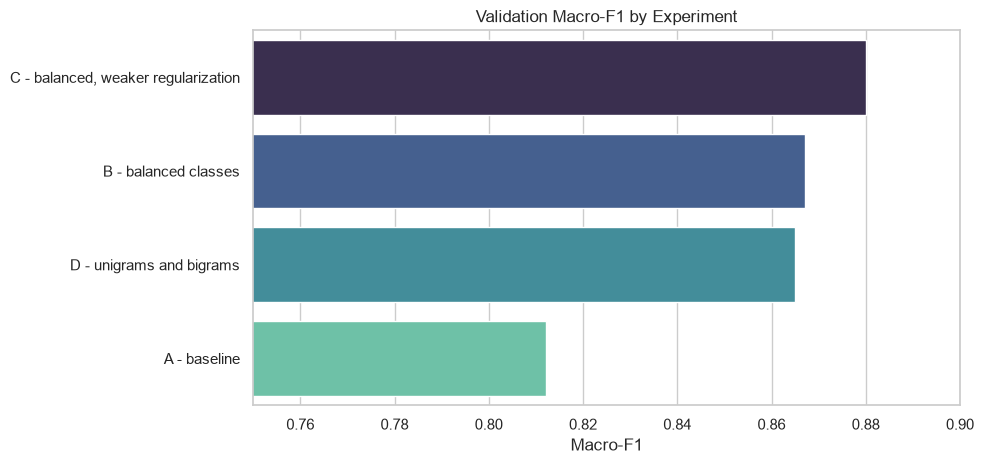

Selected configuration: C - balanced, weaker regularization
{'name': 'C - balanced, weaker regularization', 'ngram_range': (1, 1), 'max_features': 12000, 'C': 4.0, 'class_weight': 'balanced'}


In [99]:
plt.figure(figsize=(10, 4.8))
sns.barplot(
    data=results_df,
    y="experiment",
    x="validation_macro_f1",
    hue="experiment",
    legend=False,
    palette="mako",
)
plt.xlim(0.75, 0.90)
plt.title("Validation Macro-F1 by Experiment")
plt.xlabel("Macro-F1")
plt.ylabel("")
plt.tight_layout()
plt.show()

best_experiment_name = results_df.iloc[0]["experiment"]
best_config = next(item for item in experiments if item["name"] == best_experiment_name)
print("Selected configuration:", best_experiment_name)
print(best_config)

### Validation Conclusion

Balanced class weights substantially improve Macro-F1 because rare emotions contribute
more strongly to model training. Increasing `C` from 1 to 4 also improves the Validation
result by reducing regularization. Bigrams do not improve performance in this experiment;
they increase the feature space and introduce many relatively rare combinations. The
configuration with the highest Validation Macro-F1 is selected automatically.

## Final Training on Train and Validation

After selecting the hyperparameters, the vectorizer and classifier are fitted again using
all 18,000 Train and Validation samples. The Test set is still excluded from model fitting
and hyperparameter selection.

In [100]:
full_train_df = pd.concat([train_df, val_df], ignore_index=True)
y_full_train = label_encoder.transform(full_train_df["label"])
y_test = label_encoder.transform(test_df["label"])

final_vectorizer = TfidfVectorizer(
    preprocessor=clean_text,
    lowercase=False,
    ngram_range=best_config["ngram_range"],
    min_df=2,
    max_features=best_config["max_features"],
    sublinear_tf=True,
    norm="l2",
)
X_full_train = final_vectorizer.fit_transform(full_train_df["text"])
X_test = final_vectorizer.transform(test_df["text"])

final_model = LogisticRegression(
    C=best_config["C"],
    class_weight=best_config["class_weight"],
    max_iter=500,
    solver="lbfgs",
    random_state=SEED,
)
final_model.fit(X_full_train, y_full_train)

print("Final Train matrix:", X_full_train.shape)
print("Test matrix:", X_test.shape)
print("Optimization iterations:", int(final_model.n_iter_.max()))

Final Train matrix: (18000, 7748)
Test matrix: (2000, 7748)
Optimization iterations: 112


## Prediction and Final Test Evaluation

This is the first stage in which the Test labels are used for performance measurement.
The first five predictions are displayed, followed by Macro-F1, Accuracy, a per-class
report, and a confusion matrix.

In [101]:
test_probabilities = final_model.predict_proba(X_test)
test_predictions = final_model.predict(X_test)
predicted_labels = label_encoder.inverse_transform(test_predictions)

first_five_predictions = test_df.head(5).copy()
first_five_predictions["predicted_label"] = predicted_labels[:5]
first_five_predictions["confidence"] = test_probabilities[:5].max(axis=1)
display(first_five_predictions.style.format({"confidence": "{:.3f}"}))

,text,label,predicted_label,confidence
0,im feeling rather rotten so im not very ambitious right now,sadness,sadness,0.852
1,im updating my blog because i feel shitty,sadness,sadness,0.988
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,sadness,0.787
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy,joy,0.574
4,i was feeling a little vain when i did this one,sadness,sadness,0.967


In [102]:
test_macro_f1 = f1_score(y_test, test_predictions, average="macro")
test_accuracy = accuracy_score(y_test, test_predictions)

print(f"FINAL TEST MACRO-F1: {test_macro_f1:.4f}")
print(f"FINAL TEST ACCURACY: {test_accuracy:.4f}")

report_df = pd.DataFrame(
    classification_report(
        y_test,
        test_predictions,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0,
    )
).T
display(report_df.style.format("{:.4f}"))

FINAL TEST MACRO-F1: 0.8440
FINAL TEST ACCURACY: 0.8860


,precision,recall,f1-score,support
anger,0.8685,0.9127,0.8901,275.0000
fear,0.8584,0.8393,0.8488,224.0000
joy,0.9478,0.8878,0.9168,695.0000
love,0.6845,0.8868,0.7726,159.0000
sadness,0.9540,0.8933,0.9227,581.0000
surprise,0.6154,0.8485,0.7134,66.0000
accuracy,0.8860,0.8860,0.8860,0.8860
macro avg,0.8214,0.8781,0.8440,2000.0000
weighted avg,0.8968,0.8860,0.8890,2000.0000


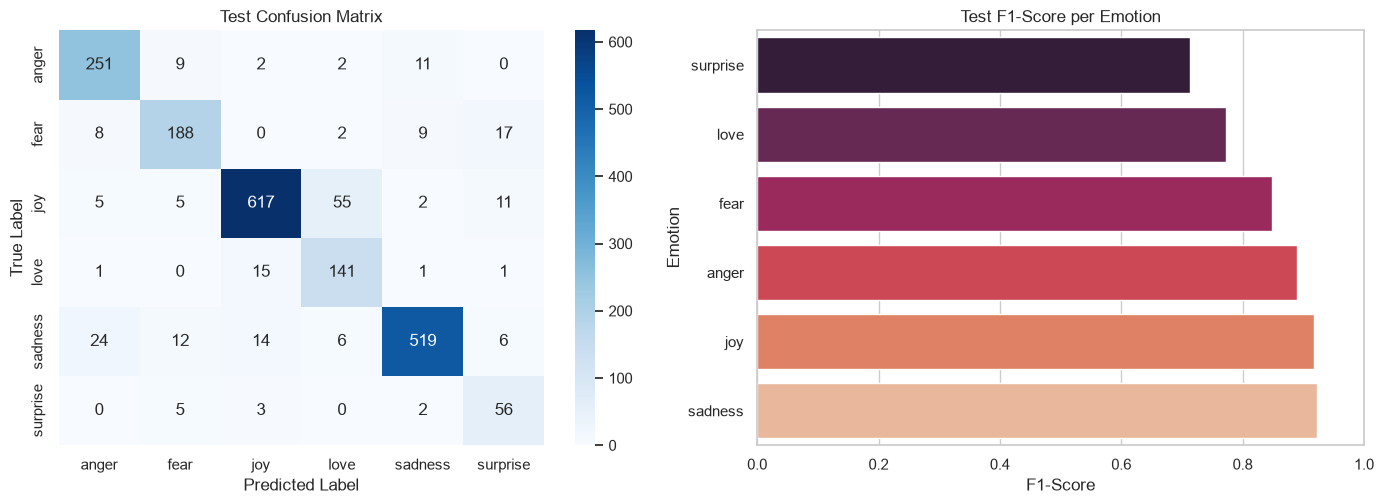

In [103]:
    matrix = confusion_matrix(y_test, test_predictions)
    per_class_f1 = report_df.loc[label_encoder.classes_, "f1-score"].sort_values()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
        ax=axes[0],
    )
    axes[0].set_title("Test Confusion Matrix")
    axes[0].set_xlabel("Predicted Label")
    axes[0].set_ylabel("True Label")

    sns.barplot(
        x=per_class_f1.values,
        y=per_class_f1.index,
        hue=per_class_f1.index,
        legend=False,
        palette="rocket",
        ax=axes[1],
    )
    axes[1].set_xlim(0, 1)
    axes[1].set_title("Test F1-Score per Emotion")
    axes[1].set_xlabel("F1-Score")
    axes[1].set_ylabel("Emotion")
    plt.tight_layout()
    plt.show()

## Model Interpretation and Error Analysis

Logistic Regression learns a coefficient for every TF-IDF feature and every class.
Features with large positive coefficients push a prediction toward the corresponding
emotion. The following table presents the highest-weight terms for each class, followed
by several high-confidence mistakes.

In [104]:
feature_names = final_vectorizer.get_feature_names_out()
top_words = {}
for class_index, class_name in enumerate(label_encoder.classes_):
    best_indices = np.argsort(final_model.coef_[class_index])[-10:][::-1]
    top_words[class_name] = feature_names[best_indices]

top_words_df = pd.DataFrame(top_words, index=[f"#{i}" for i in range(1, 11)])
display(top_words_df)

,anger,fear,joy,love,sadness,surprise
#1,resentful,pressured,superior,sympathetic,lethargic,amazed
#2,offended,terrified,satisfied,caring,punished,impressed
#3,dangerous,shaken,innocent,nostalgic,troubled,curious
#4,irritable,reluctant,sincere,tender,disturbed,surprised
#5,rushed,vulnerable,convinced,longing,melancholy,funny
#6,greedy,apprehensive,divine,horny,unfortunate,shocked
#7,distracted,uncertain,resolved,naughty,unwelcome,dazed
#8,rude,paranoid,determined,loyal,lousy,overwhelmed
#9,fucked,intimidated,successful,romantic,unimportant,amazing
#10,dissatisfied,hesitant,pleasant,liked,burdened,strange


In [105]:
error_mask = test_predictions != y_test
errors_df = test_df.loc[error_mask].copy()
errors_df["predicted_label"] = predicted_labels[error_mask]
errors_df["confidence"] = test_probabilities[error_mask].max(axis=1)
errors_df = errors_df.sort_values("confidence", ascending=False)

print(f"Misclassified Test examples: {len(errors_df)} / {len(test_df)}")
display(errors_df.head(8).style.format({"confidence": "{:.3f}"}))

Misclassified Test examples: 228 / 2000


,text,label,predicted_label,confidence
1842,i feel so amazing musicjuzz,joy,surprise,0.990
877,i feel respected and secure where i can journey toward loving and be loved in return,joy,love,0.982
1154,i feel that passionate about,joy,love,0.982
1698,i work well with almost every client ive ever been in contact with because i know what it means to feel depressed angry frustrated irritated hopeless and apathetic because i feel it daily,sadness,anger,0.958
867,i was truly surprised and feel quite honored,joy,surprise,0.955
1943,i didn t mean to get angry with you bommie i just can t control my feelings hellip i just hated myself why i am like this the dara who can t get over with that b,sadness,anger,0.954
1066,i asked some girls what it meant to them to be valued and for the most part the response was that they felt valued when the people around them made them feel valued and treated them in a loving and caring manner,joy,love,0.941
576,i feel accepted and loved by a community of derby girls that i helped to create,joy,love,0.930


### Result Analysis

The classifier performs particularly well on `sadness`, `joy`, and `anger`, which have
more training examples and clear emotion-related vocabulary. `surprise` and `love` are
more difficult because they are smaller and frequently share words with `fear` or `joy`.

TF-IDF is based mainly on word occurrence. It has limited ability to understand deep
context, irony, or complex word order. A recurrent neural network or Transformer could
model context more effectively, but would require a more complex training process.

## Predicting the Emotion of New Text

The helper function below applies the same cleaning, fitted TF-IDF transformation, and
final classifier. It returns the predicted emotion and the probability of every class.

In [106]:
def predict_emotion(text):
    features = final_vectorizer.transform([text])
    probabilities = final_model.predict_proba(features)[0]
    prediction = int(np.argmax(probabilities))
    return {
        "text": text,
        "predicted_emotion": label_encoder.inverse_transform([prediction])[0],
        "probabilities": {
            label: round(float(probability), 4)
            for label, probability in zip(label_encoder.classes_, probabilities)
        },
    }


display(pd.DataFrame([
    predict_emotion("I am so happy and excited about the good news"),
    predict_emotion("I feel nervous and worried about tomorrow"),
    predict_emotion("I miss her and feel completely empty"),
]))

,text,predicted_emotion,probabilities
0,I am so happy and excited about the good news,joy,"{'anger': 0.0048, 'fear': 0.0051, 'joy': 0.9781, 'love': 0.0047, 'sadness': 0.0067, 'surprise': 0.0007}"
1,I feel nervous and worried about tomorrow,fear,"{'anger': 0.0034, 'fear': 0.9734, 'joy': 0.0079, 'love': 0.0034, 'sadness': 0.0106, 'surprise': 0.0013}"
2,I miss her and feel completely empty,sadness,"{'anger': 0.0246, 'fear': 0.0105, 'joy': 0.0327, 'love': 0.0083, 'sadness': 0.9178, 'surprise': 0.0062}"


## Conclusion

This notebook completed a supervised text-classification workflow for emotion
recognition. The original Kaggle splits were preserved, the text was converted into
TF-IDF features, and a scikit-learn Logistic Regression classifier was trained and tuned.
Hyperparameters were selected with Validation Macro-F1 before the model was retrained and
evaluated on the Test set. The results demonstrate that a simple, interpretable linear
model can achieve strong performance, while still facing difficulty with rare emotions
and sentences that require deeper contextual understanding.